In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from google.colab import files

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

df.columns = df.columns.str.strip()

print('Columns found:', df.columns.tolist())
display(df.head())

Saving Unemployment_Rate_upto_11_2020.csv to Unemployment_Rate_upto_11_2020.csv
Columns found: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Region.1', 'longitude', 'latitude']


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [2]:

print('Missing values:\n', df.isnull().sum())

display(df.describe())

Missing values:
 Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


/tmp/ipykernel_784/2155624945.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


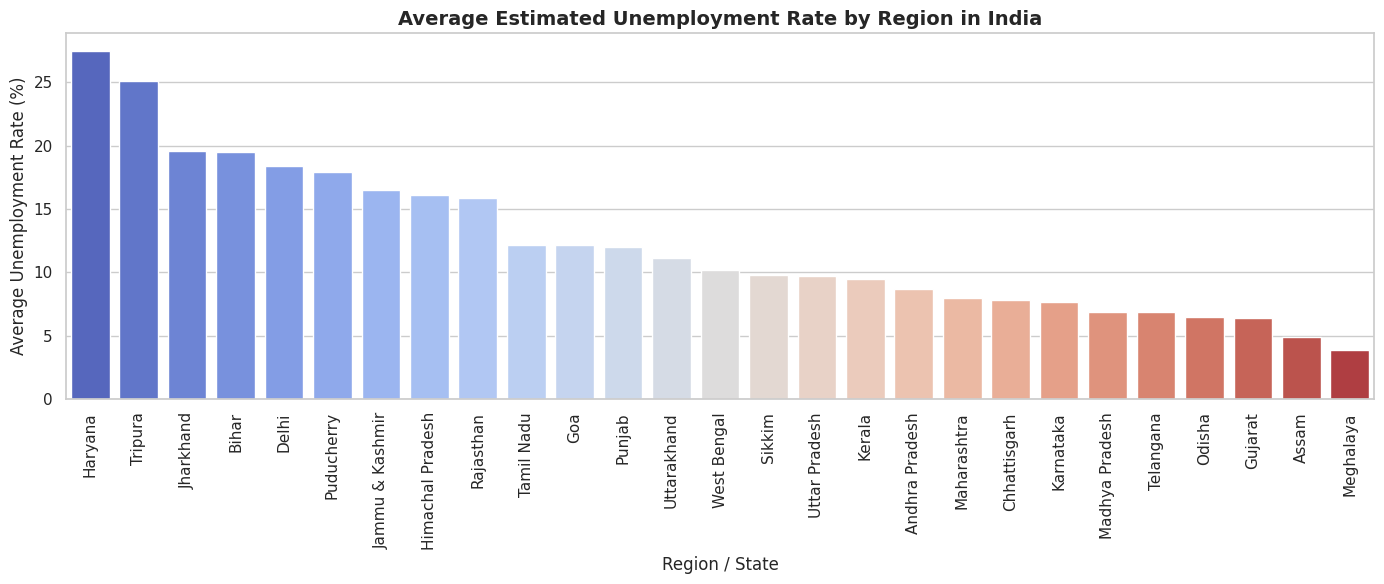

In [3]:

sns.set_theme(style='whitegrid')
plt.figure(figsize=(14, 6))

regional_unemployment = (
    df.groupby('Region')['Estimated Unemployment Rate (%)']
    .mean()
    .reset_index()
    .sort_values(by='Estimated Unemployment Rate (%)', ascending=False)
)


sns.barplot(
    data=regional_unemployment,
    x='Region',
    y='Estimated Unemployment Rate (%)',
    palette='coolwarm',
)

plt.title(
    'Average Estimated Unemployment Rate by Region in India',
    fontsize=14,
    fontweight='bold',
)
plt.xticks(rotation=90)
plt.xlabel('Region / State', fontsize=12)
plt.ylabel('Average Unemployment Rate (%)', fontsize=12)
plt.tight_layout()
plt.show()